# Group 08 — Gbagyi Track Assignment

## Indigenous Language AI Benchmark

**Group:** 08  
**Language:** Gbagyi  
**Assignment:** HW1

## Part 1 — Data Collection & Web Scraping

### Gbagyi Corpus

The corpus was collected from Gbagyi Bible text sources. The final raw corpus contains 8,088 text records stored in JSONL format.

### Data Format

Each record in `raw_data_group_08.jsonl` contains:

- `id` — unique record identifier
- `url` — source URL
- `date_retrieved` — date the data was collected
- `raw_text` — original Gbagyi text

**Total records collected:** 8,088

## Part 2 — Regex, Normalization & Tokenization

A custom rule-based tokenizer was used without NLTK or spaCy.

The preprocessing performs:

1. Unicode NFC normalization.
2. Lowercasing.
3. Preservation of Gbagyi characters and diacritics.
4. Separation of punctuation from words.
5. Whitespace normalization.
6. Space-separated token output.

The cleaned corpus is stored in:

`data/gbagyi/processed/cleaned_corpus_group_08.txt`

In [2]:
from pathlib import Path

cleaned_file = Path("../../data/gbagyi/processed/cleaned_corpus_group_08.txt")

with open(cleaned_file, "r", encoding="utf-8") as f:
    lines = [line.strip() for line in f if line.strip()]

print("Cleaned corpus lines:", len(lines))
print("First 5 tokenized lines:")
for line in lines[:5]:
    print(line)

Cleaned corpus lines: 8088
First 5 tokenized lines:
dəye nu zhni yeisu əbye masifu , dawuda nugwnu , ibrahim nugwnu : ibrahim nu ɓə zhni ishakwu dada , ishakwu nu ɓə zhni yakwuɓwu dada , yakwuɓwu nu ɓə zhni yahuda dada n əwo azajei , yahuda nu ɓə zhni perez dada n zerai , n a ɓə zhni ai yi əwo əya nge tamari nyi , perez nu ɓə zhni hezron dada , hezron nu ɓə zhni ram dada , ram nu ɓə zhni aminadab dada , aminadab nu ɓə zhni nahshon dada , nashon nu ɓə zhni salumwo dada , salumwo nu ɓə zhni bowaz dada , n a ɓə zhni ai yi əwo əya nge raham nyi , bowaz nu ɓə zhni obedi dada əwo əya ai yi nge rutu , obedi nu ɓə zhni jesse dada , jesnu jesse nu ɓə zhni əsu dawuda dada .
dawuda nu ɓə zhni sulemanu dada , ń əwo əya ɓə zhni uriya nyikwo nyi , sulemanu nu ɓə zhni rehobwowam dada , rehobwowam nu ɓə zhni abyija dada , abyija nu ɓə zhni asa dada , asa nu ɓə zhni jehoshafat dada , jehoshafat nu ɓə zhni jehoram dada , johoram nu ɓə zhni uziya dada .
uziya nu ɓə zhni jotam dada , jotam nu ɓə zhni ahaz

### Gbagyi Stopwords

A manually constructed list of 33 Gbagyi stopwords was prepared from the corpus and available Gbagyi language references. The list includes English translations for each item.

The stopword list is stored in:

`data/gbagyi/gbagyi_stopwords.csv`

**Stopword count:** 33

## Part 3 — Zipf's Law

Zipf's Law describes the relationship between a word's frequency and its rank in a corpus.

The analysis:

- Counts the frequency of each word.
- Ranks words from most frequent to least frequent.
- Uses a log-log plot of frequency against rank.
- Fits the model:

  `log(f) = C − s log(r)`

- Estimates the Zipf exponent `s`.

Total word tokens: 215416
Unique vocabulary: 5752
Estimated Zipf exponent (s): 1.509509099787576
Intercept (C): 5.579211069551619


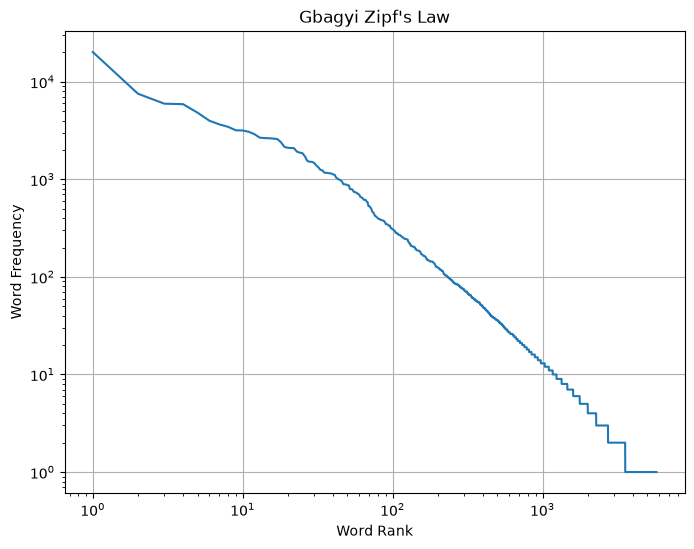

In [4]:
from collections import Counter
import math
import matplotlib.pyplot as plt

cleaned_file = "../../data/gbagyi/processed/cleaned_corpus_group_08.txt"

with open(cleaned_file, "r", encoding="utf-8") as f:
    tokens = [word for word in f.read().split() if word.isalpha()]

frequencies = Counter(tokens)

ranked = sorted(frequencies.values(), reverse=True)

log_ranks = [math.log10(rank) for rank in range(1, len(ranked) + 1)]
log_freqs = [math.log10(freq) for freq in ranked]

n = len(log_ranks)
mean_x = sum(log_ranks) / n
mean_y = sum(log_freqs) / n

slope = sum(
    (x - mean_x) * (y - mean_y)
    for x, y in zip(log_ranks, log_freqs)
) / sum(
    (x - mean_x) ** 2
    for x in log_ranks
)

intercept = mean_y - slope * mean_x

print("Total word tokens:", len(tokens))
print("Unique vocabulary:", len(frequencies))
print("Estimated Zipf exponent (s):", -slope)
print("Intercept (C):", intercept)

plt.figure(figsize=(8, 6))
plt.loglog(range(1, len(ranked) + 1), ranked)
plt.xlabel("Word Rank")
plt.ylabel("Word Frequency")
plt.title("Gbagyi Zipf's Law")
plt.grid(True)
plt.show()

### Zipf's Law Results

The Gbagyi corpus contains **215,416 word tokens** and **5,752 unique word types**.

The estimated Zipf exponent is approximately **1.51**.

This shows a strong relationship between word rank and frequency: a small number of words occur very frequently, while most words occur less frequently.

### Effect of Diacritics and Orthography

Gbagyi diacritics and tone marks were preserved during normalization. This is important because different marked forms may represent different words or grammatical forms.

Preserving diacritics can increase vocabulary size because forms that differ only in orthography are counted as separate types. Inconsistent spelling or inconsistent use of diacritics can also split the frequency of the same linguistic form across multiple word types.

## Part 4 — N-Gram Language Modeling & Perplexity

Unigram and bigram language models were implemented from scratch using dictionary-based frequency counts.

Laplace (Add-1) smoothing was applied to handle unseen words and unseen n-grams in the test set.

The models were evaluated using:

`tests/test_gbagyi_unseen.txt`

In [5]:
from collections import Counter
import math

train_file = "../../data/gbagyi/processed/cleaned_corpus_group_08.txt"
test_file = "../../tests/test_gbagyi_unseen.txt"

def read_sentences(path):
    sentences = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                sentences.append(line.split())
    return sentences

train_sentences = read_sentences(train_file)
test_sentences = read_sentences(test_file)

train_tokens = [
    word
    for sentence in train_sentences
    for word in sentence
]

test_tokens = [
    word
    for sentence in test_sentences
    for word in sentence
]

unigram_counts = Counter(train_tokens)

N = len(train_tokens)
V = len(unigram_counts)

def unigram_probability(word):
    return (unigram_counts[word] + 1) / (N + V)

unigram_log_probability = 0.0

for word in test_tokens:
    unigram_log_probability += math.log(
        unigram_probability(word)
    )

unigram_perplexity = math.exp(
    -unigram_log_probability / len(test_tokens)
)

bigram_counts = Counter()
context_counts = Counter()

for sentence in train_sentences:
    previous = "<s>"

    for word in sentence:
        bigram_counts[(previous, word)] += 1
        context_counts[previous] += 1
        previous = word

def bigram_probability(previous, word):
    return (
        bigram_counts[(previous, word)] + 1
    ) / (
        context_counts[previous] + V
    )

bigram_log_probability = 0.0
bigram_token_count = 0

for sentence in test_sentences:
    previous = "<s>"

    for word in sentence:
        bigram_log_probability += math.log(
            bigram_probability(previous, word)
        )
        bigram_token_count += 1
        previous = word

bigram_perplexity = math.exp(
    -bigram_log_probability / bigram_token_count
)

print("Training sentences:", len(train_sentences))
print("Training tokens:", N)
print("Vocabulary size (V):", V)
print("Test sentences:", len(test_sentences))
print("Test tokens:", len(test_tokens))
print()
print("Unigram perplexity:", unigram_perplexity)
print("Bigram perplexity:", bigram_perplexity)

Training sentences: 8088
Training tokens: 250485
Vocabulary size (V): 5984
Test sentences: 15
Test tokens: 142

Unigram perplexity: 2634.9358719005245
Bigram perplexity: 2951.713636206171


### N-Gram Results

The test set contains **15 sentences**.

Using Laplace (Add-1) smoothing:

- **Unigram perplexity:** approximately 2634.94
- **Bigram perplexity:** approximately 2951.71

The bigram model uses the previous word as context when estimating the probability of the next word.

## Final Assignment Summary

| Metric | Result |
|---|---:|
| Corpus lines / sentence units | 8,088 |
| Total word tokens | 215,416 |
| Unique vocabulary (V) | 5,752 |
| Zipf exponent (s) | 1.51 |
| Unigram perplexity | 2634.94 |
| Bigram perplexity | 2951.71 |

All four assignment tasks were implemented and executed in this notebook.